# Title: Child Learning vs Language Model Leraning?? 
##### *Author: Slavena Peneva-Kargiou*  
##### *Course: SoftUni Data Science* 
##### *Instructor: Yordan Darakchiev*
##### *Date: April 2026*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, mannwhitneyu
from collections import Counter
import re
import os

# 1. Introduction
My previous project in this series looked at a phoneme-triggered word recall in my two trilingual children - how many words they could produce starting with a given sound, accross Bulgarian, Greek and English. That project used linear algebra and statistics to find structure in something I had been watching informally for years.

This project starts from a similar place but asks a bigger question. My children are learning language the way all children do - through play, repetition, emotion, pointing at things, hearing the same words in different contexts, falling off bikes, meeting dogs, watching their grandmother cook. A language model learns from text. Just text, nothing else.

Both are, in some sense, learning from the same raw material. But do they end up knowing the same words? Do they learn them in the dame order? And dif not, what does the gap tell us about the difference between human and machine learning?

I will try to answer these questions combining three datasets: Wordbank, the largest empirical database of children's vocabulary acquisition accross languages; the BabyLM corpus, a carefully curated collection of child-sirected speech used to train language models; and the Brysbaert concreteness ratings, a large scale dataset of 40 000 English words rating them on how concrete or abstract they are. Together, the three datasets allow a direct data-driven comparison between what children learn, what a language model is exposed to, and where the two diverge.

# 2. The Two Learners

## 2.1 How a Child Learns Words
Children learning their first words are not passively absorbing frequency statistics. Long before they can speak, they are tracking faces, following pointing fingers, associating sounds with objects that matter to them - the bottle, the ball, the parent, etc. I have watched this process up close with my own two children and what really impressed me is how purposeful it all seems - the words that come first are the ones that are useful, concrete and repeatedly connected to something in the physical world. Hence words like "Mummy", "water", "more", "no" usually come long before words like "the", "of", "because".

This process is well documented by the MacArthur-Bated Communicative Development Inventory (CDI), the instrument behind the Wordbank database used in this project. By 18 months most children have a vocabulary of around 50 words. By 30 months that number has typically exploded to several hundred. The order in which words are acquired is surprisingly consistent accross children and even accross languages- concrete nouns and social words come first, abstract grammatical words come last.

## 2.2 How a Language Model Learns Words
Language models, on the other hand, have no bodies, no pointing fingers, no emotional response to the word "mummy". What they have is larga quantities of text and the ability to learn statistical patterns from it. Their only signal for how important a word is is how often it appears and in what contexts. A word that appears frequently and in different contexts, becomes well represented in the model's internal structure. A word that appears rarely remains poorly represented.

The BabyLM challenge, launched in 2023 and updated in 2024, asks a pointed question: what happens if you train a language model on roughly the same amount of text a child hears in the first years of their life. The resulting models are outstanding for their data size, but they still learn from text alone, with no access to the embodied, social, emotional world a child inhabits.

## 2.3 The Comparison
The gap between these two learners is the subject of this project. I frequency was all that mattered, a language model and a child should learn words in roughly the same order - the most frequent words first. If frequency is not enough, we would expect the two orderings to diverge, and the pattern of divergence could tell us something about what children have that language models don't.

# 3. The Datasets

## 3.1. Wordbank 
Wordbank (wordbank.stanford.edu) is the largest open repository of children's vocabulary development data in the world. It aggregates responsed from the MacArthur-Bates Communicative Development Inventory (CDI), a parent report instrument in which caregivers indicate which words their child inderstands and/or produces from a standardized checklist. The database currently contains data from tens of thousands of children accross more than 30 languages.

For this project I use the English (American) Words & Sentences (WS) form, which covers children aged 16 to 30 months - the window in which most of the early vocabulary explosion occurs. Each word in the dataset has a proportion value for each age in months: the fraction of children in the sample who were reported to produce that word at that age. From these proportions I derive the Age of Acquisition (AoA) for each word - defined as the youngest age at which at least 50% of children produce it. This is the standard definition used in the psycholinguistics literature.

The dataset contains 680 words accross 21 semantic categories, from animals and food to pronouns, quantifiers and connecting words. Of these, 569 reach the 50% threshold within the 16-30 month window and are assigned an AoA value. The remaining 111 words are still being learned at 30 months and are excluded from the AoA analysis.

## 3.2 BabyLM Corpus
The BabyLM corpus was created for the BabyLM Challenge, a shared task that was launched in 2023 and updated in 2024, which invites researchers to train language models on developmentally plausible amounts of text - roughly what a child is exposed to in the first years of life. The corpus is a carefully curated collection of child-directed and child-adjacent text, including transcripts from CHILDES (the Child Language Data Exchange System), children's books, subtitkes and spoken language corpora.

I use the 10 million word version of the corpus, vailable on HuggingFace. This represents approximately the amount of language input a child receives in the first three years of life - a deliberate design choice by the BabyLM organizers to make the comparison between child and model learning as direct as possible. From this corpus I compute three word-level statistics: raw frequency (how many times the word appears), mean utterance length (the average length of utterances the word appears in), and utterance diversity (how many distinct utterances contain the word). These three measures together represent everything a language model trained on this corpus knows about a word.

## 3.3. Brysbaert Concreteness Ratings
The Brysbaert et al.(2014) concreteness ratings dataset provides mean concreteness scores for 37 058 English words and 2 896 two-word expressions collected from over 4000 participants who rated each word on a 1-5 scale, from fully abstract (1) to fully concrete (5). For example, a word like "dog" receives a score close to 5, while a word like "justice" receives a score close to 1/

Concreteness is included here as a third dimension precisely because it is a human cognitive property - it reflects the degree to which a word refers to something that can be perceived, touched, or pointed at. A language model has no access to concreteness in any direct sense, it can only infer it indirectly from the statistical patterns in text. By including concreteness alongside corpus frewuency, we can ask whether the properties a model can learn from text are sufficient to explain children's word learning, or ehether something beyond text is needed. 

## 3.4 Loading the data

In [3]:
project_dir = os.path.expanduser('~/Desktop/Softuni-Data-Science-Final-Project')

# Loading the three datasets
df_wordbank  = pd.read_csv(os.path.join(project_dir, 'wordbank_item_data.csv'))
df_babylm    = pd.read_csv(os.path.join(project_dir, 'babylm_10M.csv'))
df_concrete  = pd.read_excel(os.path.join(project_dir, 'Concreteness_ratings_Brysbaert_et_al_BRM.xlsx'))

print("=== Wordbank ===")
print(f"Shape: {df_wordbank.shape}")
display(df_wordbank.head(3))

print("\n=== BabyLM ===")
print(f"Shape: {df_babylm.shape}")
display(df_babylm.head(3))

print("\n=== Brysbaert Concreteness ===")
print(f"Shape: {df_concrete.shape}")
display(df_concrete.head(3))

=== Wordbank ===
Shape: (680, 19)


,downloaded,item_id,item_definition,category,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30
0,2026-03-28,1,baa baa,sounds,0.46,0.52,0.55,0.66,0.69,0.70,0.66,0.78,0.78,0.78,0.79,0.82,0.89,0.80,0.79
1,2026-03-28,2,choo choo,sounds,0.27,0.32,0.39,0.51,0.56,0.60,0.67,0.71,0.76,0.84,0.81,0.85,0.92,0.85,0.88
2,2026-03-28,3,cockadoodledoo,sounds,0.13,0.10,0.14,0.22,0.22,0.29,0.31,0.37,0.43,0.45,0.49,0.53,0.70,0.54,0.58



=== BabyLM ===
Shape: (1058713, 1)


,text
0,aboo .
1,kee .
2,hey .



=== Brysbaert Concreteness ===
Shape: (39954, 9)


,Word,Bigram,Conc.M,Conc.SD,Unknown,Total,Percent_known,SUBTLEX,Dom_Pos
0,roadsweeper,0,4.85,0.37,1,27,0.962963,0,0
1,traindriver,0,4.54,0.71,3,29,0.896552,0,0
2,tush,0,4.45,1.01,3,25,0.880000,66,0


# 4. Data Processing and Merging

## 4.1 Computing AoA from Wordbank Proportions
Each word in the Wordbank dataset has a proportion value for each age in months - the fraction of children producing that word at that age. To derive a single AoA value per word, I find the youngest age at which this proportion first reaches or exceeds 0.50 (50%). Words that never reach this threshold within the 16-30 month window are assigned NaN and are excluded from the analysis.

In [4]:
age_cols = ['16','17','18','19','20','21','22','23','24','25','26','27','28','29','30']

def compute_aoa(row, threshold=0.5):
    """Return the first age (months) at which >= 50% of children produce the word."""
    for age in age_cols:
        if row[age] >= threshold:
            return int(age)
    return np.nan

df_wordbank['aoa'] = df_wordbank.apply(compute_aoa, axis=1)
df_wordbank['word'] = df_wordbank['item_definition'].str.lower().str.strip()
df_aoa = df_wordbank[['word', 'category', 'aoa']].copy()

print(f"Words with AoA defined (reach 50%): {df_aoa['aoa'].notna().sum()}")
print(f"Words never reaching 50% within window: {df_aoa['aoa'].isna().sum()}")
display(df_aoa.head(10))

Words with AoA defined (reach 50%): 569
Words never reaching 50% within window: 111


,word,category,aoa
0,baa baa,sounds,17.0
1,choo choo,sounds,19.0
2,cockadoodledoo,sounds,27.0
3,grrr,sounds,16.0
4,meow,sounds,18.0
5,moo,sounds,16.0
6,ouch,sounds,19.0
7,quack quack,sounds,19.0
8,uh oh,sounds,16.0
9,vroom,sounds,18.0


## 4.2 Computing Word Statistics from BabyLM
From the raw BabyLM corpus I compute three statistics for each word: frequency, mean utterance length and utterance diversity. These three measures together represent the full learning signal available to a language model trained on this corpus.

In [5]:
# Drop NaN rows
df_babylm = df_babylm.dropna(subset=['text'])
print(f"BabyLM utterances after cleaning: {len(df_babylm):,}")

word_counts = Counter()
word_utterance_lengths = {}
word_utterance_sets = {}

for text in df_babylm['text']:
    words = re.findall(r'\b[a-z]+\b', text.lower())
    utt_len = len(words)
    utt_text = text.lower().strip()
    for word in set(words):
        word_counts[word] += 1
        if word not in word_utterance_lengths:
            word_utterance_lengths[word] = []
            word_utterance_sets[word] = set()
        word_utterance_lengths[word].append(utt_len)
        word_utterance_sets[word].add(utt_text)

df_freq = pd.DataFrame({
    'word':               list(word_counts.keys()),
    'frequency':          list(word_counts.values()),
    'mean_utt_length':    [np.mean(word_utterance_lengths[w]) for w in word_counts],
    'utterance_diversity':[len(word_utterance_sets[w]) for w in word_counts]
})

print(f"Unique words in corpus: {len(df_freq):,}")
print(f"Total word tokens: {df_freq['frequency'].sum():,}")
display(df_freq.sort_values('frequency', ascending=False).head(10))

BabyLM utterances after cleaning: 1,015,493
Unique words in corpus: 135,605
Total word tokens: 8,614,586


,word,frequency,mean_utt_length,utterance_diversity
19,the,252047,21.667026,245919
31,you,176459,10.999365,154556
66,i,170603,12.557581,153282
59,to,166199,23.884253,161664
123,a,159269,24.018566,154686
209,and,159129,26.950839,156140
292,of,142454,27.547089,139598
30,it,126065,19.217015,115363
17,s,121839,17.413907,108782
84,in,119684,29.234793,117372


## 4.3 Preparing the Concreteness Dataset

In [6]:
df_concrete_clean = df_concrete[['Word', 'Conc.M']].copy()
df_concrete_clean.columns = ['word', 'concreteness']
df_concrete_clean['word'] = df_concrete_clean['word'].str.lower().str.strip()

print(f"Concreteness ratings: {len(df_concrete_clean):,} words")
print(f"Score range: {df_concrete_clean['concreteness'].min():.2f} – "
      f"{df_concrete_clean['concreteness'].max():.2f}")
display(df_concrete_clean.head(5))

Concreteness ratings: 39,954 words
Score range: 1.04 – 5.00


,word,concreteness
0,roadsweeper,4.85
1,traindriver,4.54
2,tush,4.45
3,hairdress,3.93
4,pharmaceutics,3.77


## 4.4 Merging the Three Datasets
The three datasets are merged on the word as a common key. Because Wordbank contains only early childhood vocabulary (680 words) while the BabyLM corpus contains 135 605 unique tokens and Brysbaert covers nearly 40 000 words, the merge is left-joined on Wordbank - every Wordbank word is kept and corpus and concreteness values are added where available.

In [8]:
df_merged = df_aoa\
    .merge(df_freq, on='word', how='left')\
    .merge(df_concrete_clean, on='word', how='left')

print(f"Total Wordbank words:          {len(df_merged)}")
print(f"With frequency data:           {df_merged['frequency'].notna().sum()}")
print(f"With concreteness data:        {df_merged['concreteness'].notna().sum()}")
print(f"With all three variables:      "
      f"{df_merged[['aoa','frequency','concreteness']].notna().all(axis=1).sum()}")

# Final analysis dataset — words with all three variables defined
df_analysis = df_merged[
    df_merged['aoa'].notna() &
    df_merged['frequency'].notna() &
    df_merged['concreteness'].notna()
].copy().reset_index(drop=True)

print(f"\nFinal analysis dataset: {len(df_analysis)} words")
display(df_analysis.head(10))

Total Wordbank words:          680
With frequency data:           593
With concreteness data:        588
With all three variables:      473

Final analysis dataset: 473 words


,word,category,aoa,frequency,mean_utt_length,utterance_diversity,concreteness
0,meow,sounds,18.0,53.0,4.943396,21.0,3.92
1,moo,sounds,16.0,49.0,14.693878,40.0,3.40
2,ouch,sounds,19.0,78.0,4.653846,39.0,2.76
3,alligator,animals,27.0,44.0,20.386364,40.0,4.96
4,animal,animals,25.0,745.0,37.348993,732.0,4.61
5,ant,animals,26.0,39.0,41.974359,39.0,4.86
6,bear,animals,21.0,928.0,30.796336,881.0,4.88
7,bee,animals,23.0,161.0,28.720497,152.0,4.88
8,bird,animals,19.0,734.0,38.344687,708.0,5.00
9,bug,animals,23.0,134.0,18.962687,125.0,5.00


The 87 words missing from the corpus are mainly multy-word entries such as "baa baa", "choo choo" and "uh oh" - onomatopoeia and sound words that appear as compound tokens in Wordbank but are not tokenized as single words in the corpus. This is an interesting finding - the words most characteristic of child-directed speech are the ones that are least well represented in the model's training data.

# 5. Exploratory Data Analysis

## 5.1 Wordbank - AoA Distribution and Category Breakdown

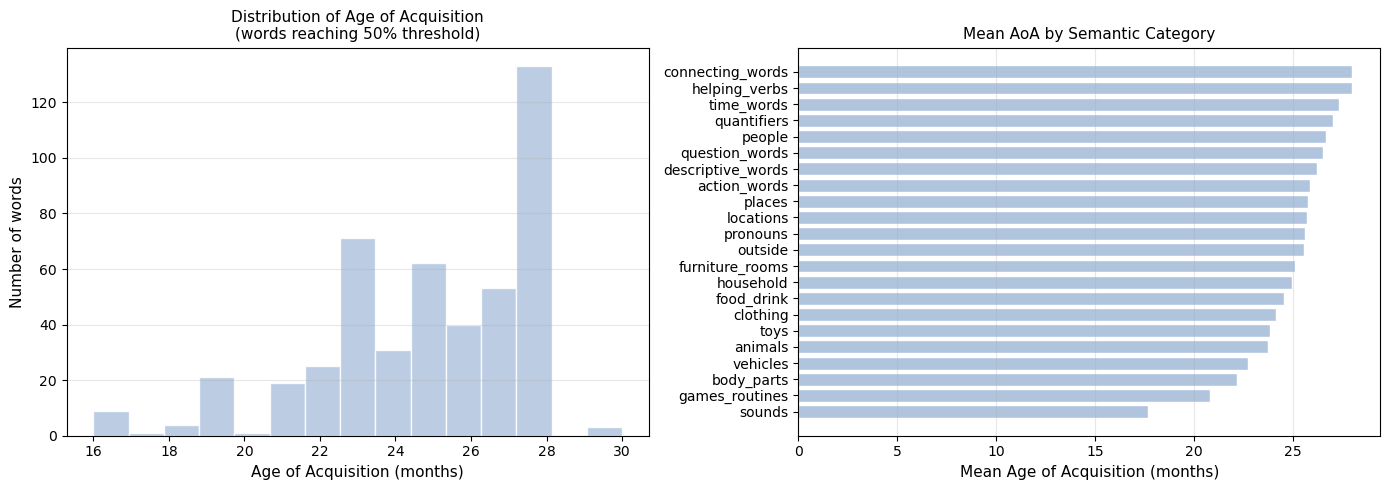


AoA summary statistics:
count    473.00
mean      24.97
std        2.96
min       16.00
25%       23.00
50%       25.00
75%       28.00
max       30.00
Name: aoa, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AoA distribution
axes[0].hist(df_analysis['aoa'], bins=15, color='lightsteelblue',
             edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Age of Acquisition (months)', fontsize=11)
axes[0].set_ylabel('Number of words', fontsize=11)
axes[0].set_title('Distribution of Age of Acquisition\n(words reaching 50% threshold)',
                  fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Mean AoA by category
cat_aoa = df_analysis.groupby('category')['aoa'].mean().sort_values()
axes[1].barh(cat_aoa.index, cat_aoa.values, color='lightsteelblue',
             edgecolor='white')
axes[1].set_xlabel('Mean Age of Acquisition (months)', fontsize=11)
axes[1].set_title('Mean AoA by Semantic Category', fontsize=11)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nAoA summary statistics:")
print(df_analysis['aoa'].describe().round(2))

## 5.2 BabyLM - Frequency Distribution and Zipf's Law
One of the most well-known properties of natural language is Zipf's law - word frequency follows a power law distribution where a small number of words account for the vas majority of occurencies. A language model trained on such a corpus sees some words thousands of times and most words only rarely. This is the fundamental assymetry that makes frequency a poor learning signal for rare but important words.

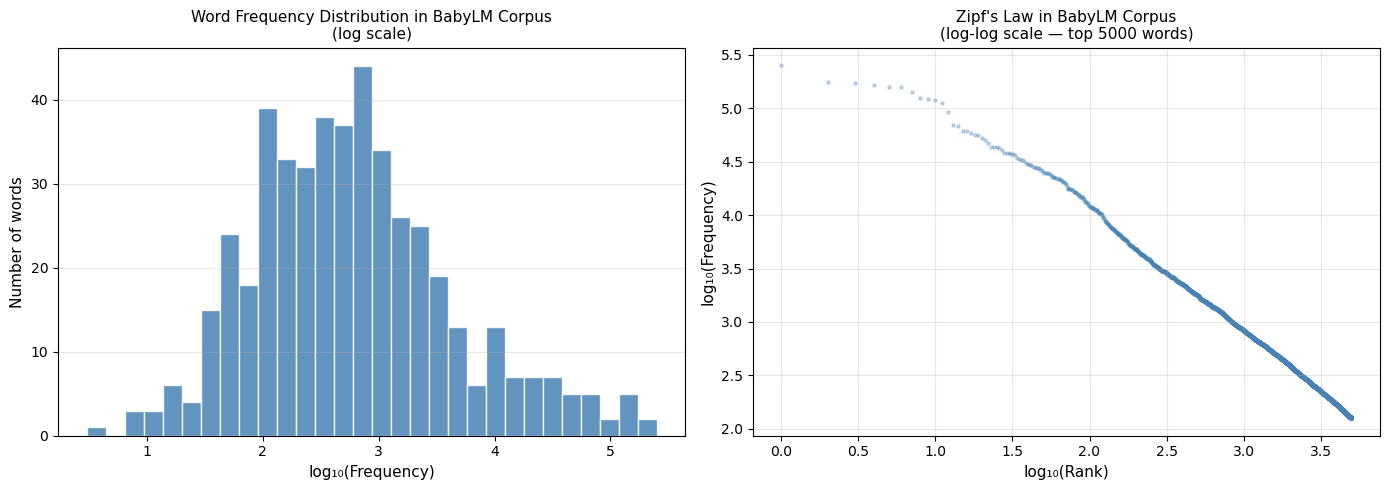


Frequency summary statistics (analysis dataset):
count       473.00
mean       6207.73
std       23621.99
min           2.00
25%         138.00
50%         506.00
75%        1750.00
max      252047.00
Name: frequency, dtype: float64


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Frequency distribution (log scale)
axes[0].hist(np.log10(df_analysis['frequency'] + 1), bins=30,
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('log₁₀(Frequency)', fontsize=11)
axes[0].set_ylabel('Number of words', fontsize=11)
axes[0].set_title('Word Frequency Distribution in BabyLM Corpus\n(log scale)',
                  fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Zipf's law: rank vs frequency on log-log scale
freq_sorted = df_freq.sort_values('frequency', ascending=False).reset_index(drop=True)
freq_sorted['rank'] = freq_sorted.index + 1

axes[1].scatter(np.log10(freq_sorted['rank'][:5000]),
                np.log10(freq_sorted['frequency'][:5000]),
                alpha=0.3, s=5, color='steelblue')
axes[1].set_xlabel('log₁₀(Rank)', fontsize=11)
axes[1].set_ylabel('log₁₀(Frequency)', fontsize=11)
axes[1].set_title("Zipf's Law in BabyLM Corpus\n(log-log scale — top 5000 words)",
                  fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nFrequency summary statistics (analysis dataset):")
print(df_analysis['frequency'].describe().round(2))

## 5.3 Brysbaert - Concreteness Distribution

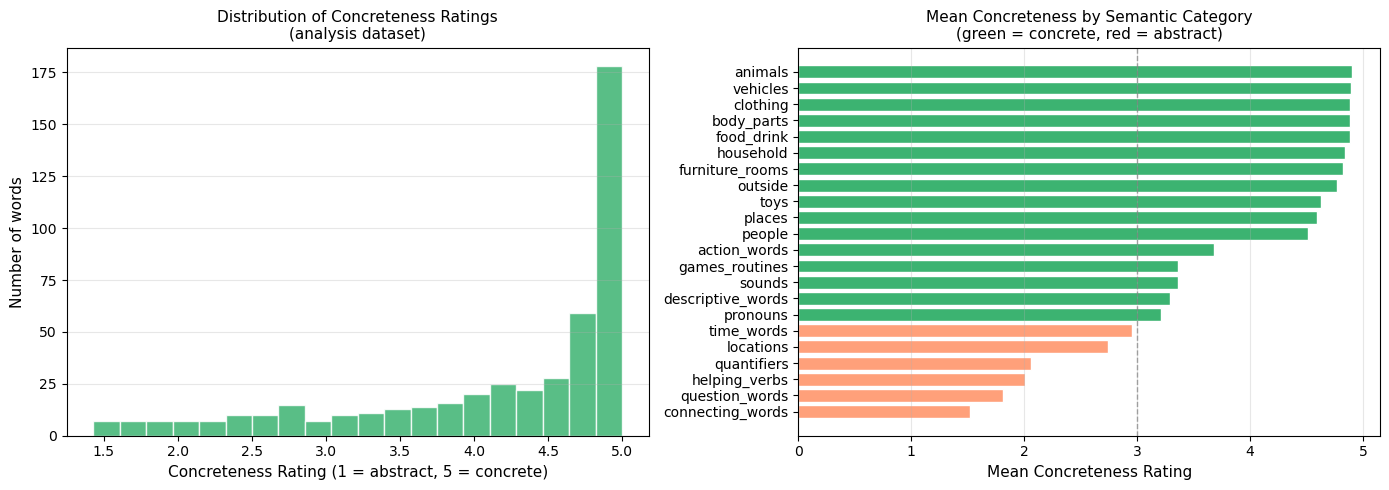


Concreteness summary statistics:
count    473.00
mean       4.17
std        0.97
min        1.43
25%        3.71
50%        4.67
75%        4.90
max        5.00
Name: concreteness, dtype: float64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall concreteness distribution
axes[0].hist(df_analysis['concreteness'], bins=20,
             color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Concreteness Rating (1 = abstract, 5 = concrete)', fontsize=11)
axes[0].set_ylabel('Number of words', fontsize=11)
axes[0].set_title('Distribution of Concreteness Ratings\n(analysis dataset)',
                  fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Mean concreteness by category
cat_concrete = df_analysis.groupby('category')['concreteness'].mean().sort_values()
colors = ['lightsalmon' if v < 3 else 'mediumseagreen' for v in cat_concrete.values]
axes[1].barh(cat_concrete.index, cat_concrete.values, color=colors,
             edgecolor='white')
axes[1].axvline(3, color='grey', linestyle='--', linewidth=1, alpha=0.7)
axes[1].set_xlabel('Mean Concreteness Rating', fontsize=11)
axes[1].set_title('Mean Concreteness by Semantic Category\n'
                  '(green = concrete, red = abstract)', fontsize=11)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nConcreteness summary statistics:")
print(df_analysis['concreteness'].describe().round(2))

## 5.4 What Getls Lost in the Merge and Why

In [12]:
# Words missing from corpus
missing_corpus = df_merged[df_merged['frequency'].isna()]['word'].tolist()
missing_concrete = df_merged[df_merged['concreteness'].isna() &
                              df_merged['frequency'].notna()]['word'].tolist()

print(f"Words missing from BabyLM corpus ({len(missing_corpus)}):")
print(missing_corpus[:20])

print(f"\nWords in corpus but missing concreteness ratings ({len(missing_concrete)}):")
print(missing_concrete[:20])

Words missing from BabyLM corpus (87):
['baa baa', 'choo choo', 'cockadoodledoo', 'quack quack', 'uh oh', 'woof woof', 'yum yum', 'chicken (animal)', 'fish (animal)', 'teddybear', 'play dough', 'toy (object)', 'chicken (food)', 'drink (beverage)', 'fish (food)', 'french fries', 'green beans', 'ice cream', 'orange (food)', 'peanut butter']

Words in corpus but missing concreteness ratings (16):
['grrr', 'vroom', 'bubbles', 'beans', 'carrots', 'cheerios', 'grapes', 'jello', 'nuts', 'peas', 'beads', 'gloves', 'mittens', 'lips', 'keys', 'pattycake']


The words missing from the corpus are telling. Almost all are multi-word entries - "baa baa", "uh oh", "yum yum" - the playful repetitive onomatopoeic language that is most characteristic of caregiver speech to young children. These words are among the earliest learned in Wordbank, yet they are invisible to the corpus based model because they do not tokenize as single words. This is the first sign that the model's representation of child-directed speech is systematically incomplete in exactly the ways that matter most for early word learning.

# 6. Comparison

# 7. Hypothesis Testing

# 8. Discussion

## 8.1 Key Findings

## 8.2 Limitations

# 9. Conclusion

# 10. References